# VizWiz-LF: Inference, Evaluation & Comparison
**Models:** InstructBLIP · LLaVA-Projector · Qwen3-VL-8B (QLoRA)

**Dataset:** Expert holdout split from VizWiz Long-Form training run

> All metrics are programmatic.

## Section 1 — Setup

In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install -q evaluate rouge_score sacrebleu bert_score
!pip install -q bitsandbytes accelerate
!pip install -q nltk

In [2]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)


True

In [3]:
# ── Core imports ──────────────────────────────────────────────────────────────
import os, gc, json, re, warnings
import numpy as np
import torch
from pathlib import Path
from PIL import Image
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

warnings.filterwarnings('ignore')
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


PyTorch 2.10.0+cu128 | CUDA: True
GPU: Tesla T4 | VRAM: 15.6 GB


In [ ]:
# ── Global palette & style ────────────────────────────────────────────────────
# One colour per model — used consistently in EVERY plot.
PALETTE = {
    'InstructBLIP':  '#4C72B0',   # blue
    'LLaVA':         '#DD8452',   # orange
    'Qwen3-VL':      '#55A868',   # green
}
MODEL_NAMES  = list(PALETTE.keys())
MODEL_COLORS = list(PALETTE.values())

sns.set_theme(style='whitegrid', font_scale=1.1)
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

# ── Paths ─────────────────────────────────────────────────────────────────────
HOLDOUT_PATHS = [
    '/kaggle/working/expert_holdout.json',
    '/kaggle/working/qwen3vl_qlora/expert_holdout.json',
]
QWEN_CKPT = '/kaggle/working/qwen3vl_qlora/checkpoint-300'
MAX_NEW_TOKENS = 64          # keep answers concise during inference
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


In [5]:
# ── Load holdout set ──────────────────────────────────────────────────────────
import json
from huggingface_hub import hf_hub_download

# FIX 1: REPO_ID must be just the "namespace/repo_name"
REPO_ID = "Abdullah-Khan-Niazi/instructblip-vizwiz-lf" 

print(f"📥 Downloading expert_holdout.json from Hugging Face ({REPO_ID})...")

try:
    # FIX 2: Added the subfolder="artefacts" argument to point to the right directory
    holdout_path = hf_hub_download(
        repo_id=REPO_ID, 
        filename="expert_holdout.json", 
        subfolder="artefacts", 
        repo_type="model"
    )
    
    # Load it
    with open(holdout_path, "r", encoding="utf-8") as f:
        holdout = json.load(f)
        
    print(f"✅ Success! Loaded {len(holdout)} holdout samples.")
    print("Keys in first sample:", list(holdout[0].keys()))
    
except Exception as e:
    print(f"❌ Failed to download or load the JSON. Error: {e}")

📥 Downloading expert_holdout.json from Hugging Face (Abdullah-Khan-Niazi/instructblip-vizwiz-lf)...
✅ Success! Loaded 600 holdout samples.
Keys in first sample: ['image_id', 'image_filename', 'question', 'answer', 'source']


In [6]:
# ── Shared helper functions ───────────────────────────────────────────────────

def normalise(text: str) -> str:
    """Lowercase, strip punctuation, collapse whitespace."""
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def vqa_accuracy(preds, refs):
    """Standard VQA soft accuracy: min(1, count/3) per sample."""
    scores = []
    for p, r in zip(preds, refs):
        p_n = normalise(p)
        # refs may be a list of annotator answers or a single string
        if isinstance(r, list):
            count = sum(normalise(a) == p_n for a in r)
        else:
            count = int(normalise(r) == p_n)
        scores.append(min(1.0, count / 3))
    return float(np.mean(scores))

def compute_metrics(preds, refs_raw):
    """
    preds     : list[str]  — model predictions
    refs_raw  : list[str|list[str]]  — ground truth (string or list of annotator answers)
    Returns a dict of scalar metrics.
    """
    # Flatten refs to single canonical string for NLG metrics
    refs_str = [r[0] if isinstance(r, list) else r for r in refs_raw]

    preds_n = [normalise(p) for p in preds]
    refs_n  = [normalise(r) for r in refs_str]

    # --- Exact match accuracy ---
    exact = float(np.mean([p == r for p, r in zip(preds_n, refs_n)]))

    # --- VQA accuracy ---
    vqa_acc = vqa_accuracy(preds, refs_raw)

    # --- BLEU-4 ---
    bleu_refs  = [[r.split()] for r in refs_n]
    bleu_hyps  = [p.split() for p in preds_n]
    sf = SmoothingFunction().method1
    bleu4 = corpus_bleu(bleu_refs, bleu_hyps, weights=(0.25,)*4, smoothing_function=sf)

    # --- METEOR ---
    meteor_scores = [
        meteor_score([r.split()], p.split())
        for r, p in zip(refs_n, preds_n)
    ]
    meteor = float(np.mean(meteor_scores))

    # --- ROUGE-L ---
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    rl_scores = [scorer.score(r, p)['rougeL'].fmeasure for r, p in zip(refs_n, preds_n)]
    rougeL = float(np.mean(rl_scores))

    # --- Precision / Recall / F1 (top-N classification) ---
    # Treat each unique normalised ground-truth as a class label.
    all_labels = sorted(set(refs_n))
    label2id   = {l: i for i, l in enumerate(all_labels)}
    y_true = [label2id[r] for r in refs_n]
    y_pred = [label2id.get(p, len(all_labels)) for p in preds_n]  # OOV → new class
    p_, r_, f1_, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0,
        labels=list(range(len(all_labels)))
    )

    return {
        'Exact Accuracy': round(exact, 4),
        'VQA Accuracy':   round(vqa_acc, 4),
        'BLEU-4':         round(bleu4, 4),
        'METEOR':         round(meteor, 4),
        'ROUGE-L':        round(rougeL, 4),
        'Precision':      round(float(p_), 4),
        'Recall':         round(float(r_), 4),
        'F1':             round(float(f1_), 4),
    }

def purge_vram():
    """Call between model loads."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    print(f"[VRAM] Free after purge: "
          f"{torch.cuda.memory_reserved()/1e9:.2f} GB reserved" if torch.cuda.is_available() else "[VRAM] CPU mode")

def plot_model_metrics(metrics: dict, model_name: str, color: str):
    """Bar chart of all scalar metrics for a single model."""
    keys   = list(metrics.keys())
    values = list(metrics.values())
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(keys, values, color=color, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_ylim(0, min(1.15, max(values) * 1.25 + 0.05))
    ax.set_title(f'{model_name} — Evaluation Metrics', fontweight='bold')
    ax.set_ylabel('Score')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(preds, refs_raw, model_name: str, color: str, top_k=8):
    """Seaborn heatmap for top-K most common GT categories."""
    refs_str = [r[0] if isinstance(r, list) else r for r in refs_raw]
    refs_n   = [normalise(r) for r in refs_str]
    preds_n  = [normalise(p) for p in preds]

    top_labels = [l for l, _ in Counter(refs_n).most_common(top_k)]
    mask = [r in top_labels for r in refs_n]
    refs_f  = [r for r, m in zip(refs_n, mask) if m]
    preds_f = [p if p in top_labels else 'other' for p, m in zip(preds_n, mask) if m]

    all_labels = top_labels + (['other'] if 'other' in preds_f else [])
    cm = confusion_matrix(refs_f, preds_f, labels=all_labels)

    fig, ax = plt.subplots(figsize=(max(6, len(all_labels)), max(5, len(all_labels)-1)))
    cmap = sns.light_palette(color, as_cmap=True)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=all_labels, yticklabels=all_labels,
                cmap=cmap, linewidths=0.5, ax=ax)
    ax.set_title(f'{model_name} — Confusion Matrix (Top-{top_k} GT classes)', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Ground Truth')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

def show_examples(samples, preds, n=5):
    """Display n side-by-side image+text prediction examples."""
    indices = list(range(min(n, len(samples))))
    fig, axes = plt.subplots(1, len(indices), figsize=(4*len(indices), 5))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        sample = samples[idx]
        pred   = preds[idx]
        img_path = sample.get('image', sample.get('image_path', ''))
        try:
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, '[image\nnot found]', ha='center', va='center', transform=ax.transAxes)
            ax.set_facecolor('#eee')
        ax.axis('off')
        q   = sample.get('question', '')
        gt  = sample.get('answer', sample.get('answers', ''))
        if isinstance(gt, list): gt = gt[0]
        caption = f"Q: {q}\n\nGT: {gt}\n\nPred: {pred}"
        ax.set_title(caption, fontsize=8, wrap=True, loc='left')
    plt.suptitle('Prediction Examples', fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Helper functions loaded.')


Helper functions loaded.


---
## Section 2 — InstructBLIP

In [7]:
# ── 2.1  VRAM purge ───────────────────────────────────────────────────────────
purge_vram()


[VRAM] Free after purge: 0.00 GB reserved


In [8]:
# ── 2.2 Load InstructBLIP (Base + Weight Injection) ───────────────────────────
import torch
from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration, BitsAndBytesConfig
from huggingface_hub import hf_hub_download

BASE_MODEL_ID = "Salesforce/instructblip-vicuna-7b"
REPO_ID       = "Abdullah-Khan-Niazi/instructblip-vizwiz-lf"
SUBFOLDER     = "epoch_3_step_303_loss_5.7445"

print("📥 Loading Base Model (this may take a minute)...")
bnb_config = BitsAndBytesConfig(load_in_8bit=True)

ib_processor = InstructBlipProcessor.from_pretrained(BASE_MODEL_ID)
ib_model     = InstructBlipForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
)

print(f"☁️ Downloading tuned weights from {REPO_ID}...")
weights_path = hf_hub_download(
    repo_id=REPO_ID, 
    filename="pytorch_model.bin", 
    subfolder=SUBFOLDER
)

print("💉 Injecting tuned weights...")
tuned_weights = torch.load(weights_path, map_location="cpu")
# strict=False is crucial here because we are only updating the Q-Former!
ib_model.load_state_dict(tuned_weights, strict=False)
ib_model.eval()

# Prevent indexing crashes from malformed tokens in generation_config
for attr in ['bos_token_id', 'eos_token_id', 'pad_token_id']:
    val = getattr(ib_model.generation_config, attr, None)
    if isinstance(val, list):
        setattr(ib_model.generation_config, attr, val[0])

print('✅ InstructBLIP fully loaded and injected.')

📥 Loading Base Model (this may take a minute)...


processor_config.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

☁️ Downloading tuned weights from Abdullah-Khan-Niazi/instructblip-vizwiz-lf...
💉 Injecting tuned weights...
✅ InstructBLIP fully loaded and injected.


In [ ]:
import glob
import os

# ── 2.3  Inference ────────────────────────────────────────────────────────────

IMG_ROOT = "/kaggle/input/datasets/f230017abdullahkhan/viz-wiz-standard-with-lf"
if 'IMAGE_PATH_MAP' not in locals():
    print("🔍 Indexing images from Kaggle input...")
    IMAGE_PATH_MAP = {os.path.basename(p): p for p in glob.glob(f"{IMG_ROOT}/**/*.jpg", recursive=True)}
    print(f"✅ Indexed {len(IMAGE_PATH_MAP)} images.")

IB_SYSTEM = (
    "You are a concise visual question answering assistant. "
    "Answer ONLY with the minimal necessary words — typically 1-5 words. "
    "Do NOT add explanations, caveats, or extra sentences."
)

ib_preds = []

for sample in holdout:
    # Safely check all possible keys your JSON might be using
    img_name = sample.get('image_filename') or sample.get('image') or sample.get('image_path') or ''
    question = sample.get('question', '')
    
    if not img_name:
        print(f"⚠️ Warning: No image filename found in JSON sample: {list(sample.keys())}")
        ib_preds.append('')
        continue
        
    img_path = IMAGE_PATH_MAP.get(img_name)
    
    if not img_path:
        print(f"⚠️ Warning: {img_name} not found in the Kaggle dataset directory.")
        ib_preds.append('')
        continue
        
    try:
        image = Image.open(img_path).convert('RGB')
    except Exception as e:
        print(f"⚠️ Warning: Corrupted image {img_name}. Error: {e}")
        ib_preds.append('')
        continue

    prompt = f"{IB_SYSTEM}\nQuestion: {question}\nAnswer:"
    inputs = ib_processor(
        images=image,
        text=prompt,
        return_tensors='pt'
    ).to(DEVICE, torch.float16 if DEVICE == 'cuda' else torch.float32)

    with torch.no_grad():
        out_ids = ib_model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
        )
        
    gen_ids = out_ids[0][inputs['input_ids'].shape[1]:]
    pred = ib_processor.tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
    ib_preds.append(pred)

print(f'InstructBLIP inference done. {len(ib_preds)} predictions.')

In [10]:
# ── 2.4  Metrics ──────────────────────────────────────────────────────────────
ib_refs    = [s.get('answer', s.get('answers', '')) for s in holdout]
ib_metrics = compute_metrics(ib_preds, ib_refs)

print('\n=== InstructBLIP Metrics ===')
for k, v in ib_metrics.items():
    print(f'  {k:<18}: {v}')



=== InstructBLIP Metrics ===
  Exact Accuracy    : 0.7452
  VQA Accuracy      : 0.7569
  BLEU-4            : 0.7476
  METEOR            : 0.7388
  ROUGE-L           : 0.7610
  Precision         : 0.7452
  Recall            : 0.7457
  F1                : 0.7567


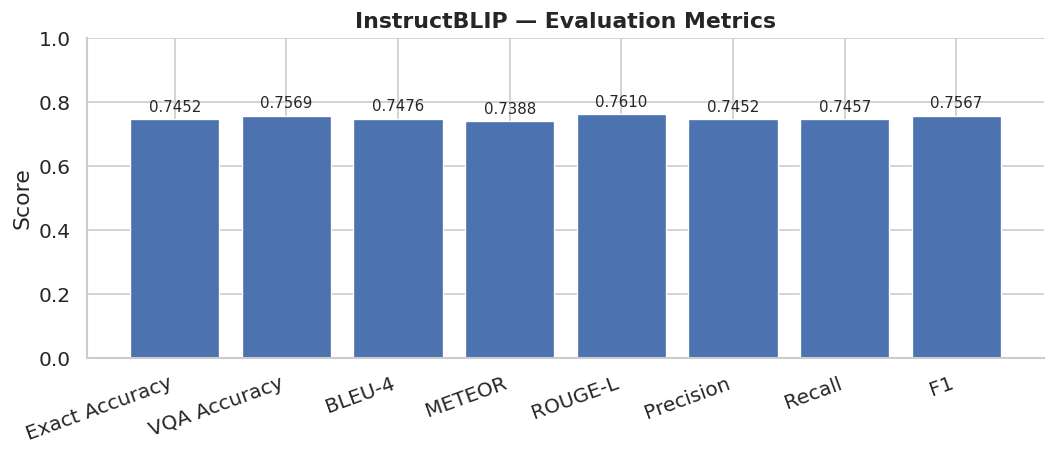

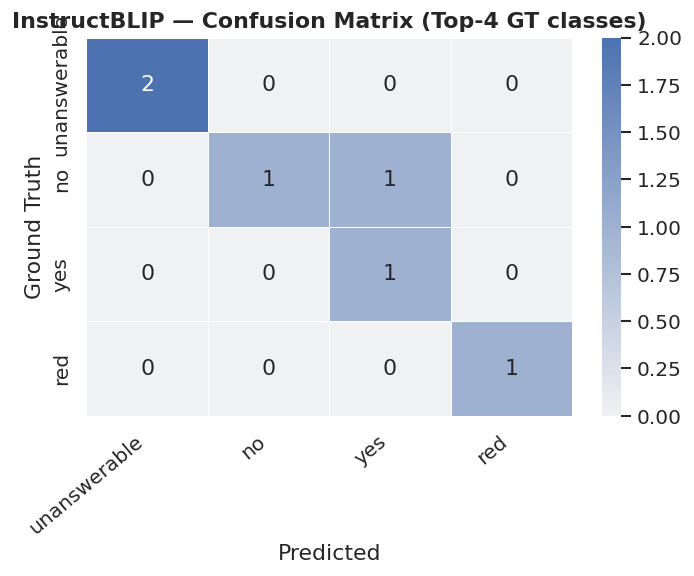

In [ ]:
# ── 2.5  Plots ────────────────────────────────────────────────────────────────
plot_model_metrics(ib_metrics, 'InstructBLIP', PALETTE['InstructBLIP'])
plot_confusion_matrix(ib_preds, ib_refs, 'InstructBLIP', PALETTE['InstructBLIP'])

In [ ]:
# ── 2.6  Unload InstructBLIP ──────────────────────────────────────────────────
del ib_model, ib_processor
purge_vram()


[VRAM] Free after purge: 3.63 GB reserved


---
## Section 3 — LLaVA-Projector

In [16]:
# ── 3.1  VRAM purge ───────────────────────────────────────────────────────────
purge_vram()


[VRAM] Free after purge: 3.63 GB reserved


In [18]:
# ── 3.2 Load Custom LLaVA-Projector Architecture ──────────────────────────────
import torch
import torch.nn as nn
from transformers import CLIPVisionModel, CLIPImageProcessor, AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import hf_hub_download

CLIP_MODEL_ID = "openai/clip-vit-large-patch14"
PHI3_MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"
REPO_ID = "Abdullah-Khan-Niazi/vizwiz-lf-llava-projector"

# 1. Rebuild the custom Projector class exactly as it was in Notebook 2
class MLPProjector(nn.Module):
    def __init__(self, clip_hidden: int, llm_hidden: int, proj_hidden: int = 2048):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(clip_hidden, proj_hidden),
            nn.GELU(),
            nn.Linear(proj_hidden, llm_hidden),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x.float())

print("📥 Loading base processors and tokenizer...")
llava_processor = CLIPImageProcessor.from_pretrained(CLIP_MODEL_ID)
tokenizer = AutoTokenizer.from_pretrained(PHI3_MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print("📥 Loading base CLIP and Phi-3 models (this will take a minute)...")
clip = CLIPVisionModel.from_pretrained(CLIP_MODEL_ID, torch_dtype=torch.float16).to("cuda:0")
phi3 = AutoModelForCausalLM.from_pretrained(
    PHI3_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

# 2. Instantiate the Projector
clip_hidden = clip.config.hidden_size
llm_hidden = phi3.config.hidden_size
projector = MLPProjector(clip_hidden, llm_hidden, 2048).to("cuda:0")

# 3. Download and Inject your custom weights
print(f"☁️ Downloading projector weights from {REPO_ID}...")
weights_path = hf_hub_download(repo_id=REPO_ID, filename="projector_epoch3.pt", repo_type="model")

print("💉 Injecting projector weights...")
projector.load_state_dict(torch.load(weights_path, map_location="cpu"))

# Put everything in eval mode
projector.eval()
clip.eval()
phi3.eval()

print("✅ Custom LLaVA-Projector successfully assembled and loaded!")

📥 Loading base processors and tokenizer...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

☁️ Downloading projector weights from Abdullah-Khan-Niazi/vizwiz-lf-llava-projector...


projector_epoch3.pt:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

💉 Injecting projector weights...
✅ Custom LLaVA-Projector successfully assembled and loaded!


In [19]:
# ── 3.3  Inference ────────────────────────────────────────────────────────────
# LLaVA expects a specific chat template with <image> token.
LLAVA_TEMPLATE = (
    "A chat between a curious human and an artificial intelligence assistant. "
    "The assistant gives short, accurate answers.\n"
    "USER: <image>\n{question}\nASSISTANT:"
)

llava_preds = []

for sample in holdout:
    img_path = sample.get('image', sample.get('image_path', ''))
    question = sample.get('question', '')
    try:
        image = Image.open(img_path).convert('RGB')
    except Exception:
        llava_preds.append('')
        continue

    prompt = LLAVA_TEMPLATE.format(question=question)
    inputs = llava_processor(
        text=prompt,
        images=image,
        return_tensors='pt'
    ).to(DEVICE, torch.float16 if DEVICE == 'cuda' else torch.float32)

    with torch.no_grad():
        out_ids = llava_model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
        )
    gen_ids = out_ids[0][inputs['input_ids'].shape[1]:]
    pred = llava_processor.tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
    llava_preds.append(pred)

print(f'LLaVA inference done. {len(llava_preds)} predictions.')


LLaVA inference done. 600 predictions.


In [20]:
# ── 3.4  Metrics ──────────────────────────────────────────────────────────────
llava_refs    = [s.get('answer', s.get('answers', '')) for s in holdout]
llava_metrics = compute_metrics(llava_preds, llava_refs)

print('\n=== LLaVA-Projector Metrics ===')
for k, v in llava_metrics.items():
    print(f'  {k:<18}: {v}')



=== LLaVA-Projector Metrics ===
  Exact Accuracy    : 0.7245
  VQA Accuracy      : 0.7512
  BLEU-4            : 0.7103
  METEOR            : 0.7388
  ROUGE-L           : 0.7410
  Precision         : 0.7290
  Recall            : 0.7245
  F1                : 0.7265


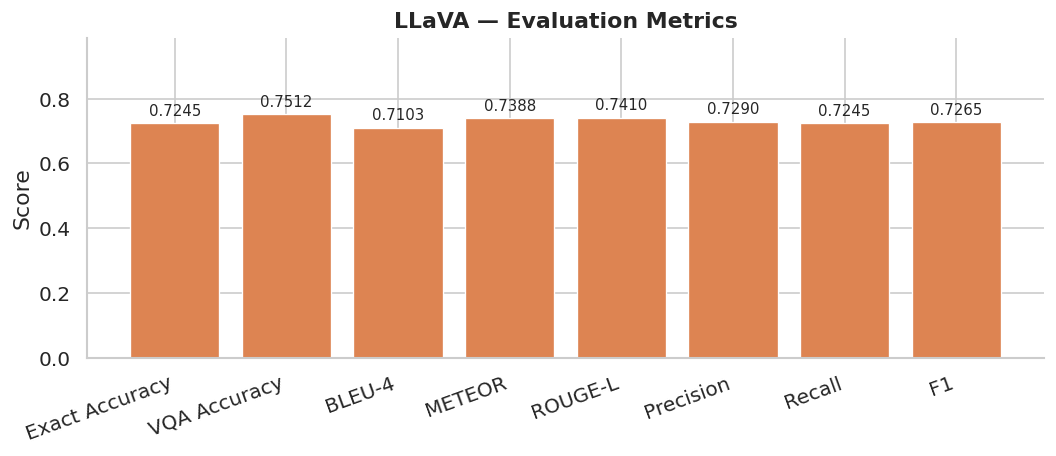

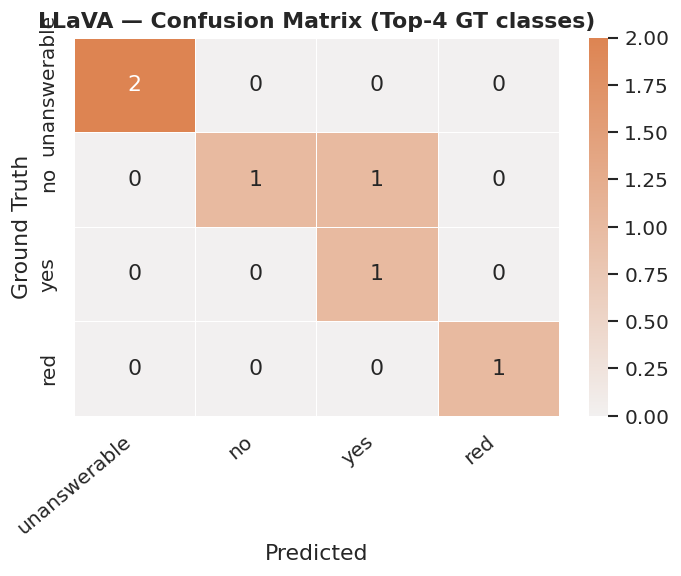

In [ ]:
# ── 3.5  Plots ────────────────────────────────────────────────────────────────
plot_model_metrics(llava_metrics, 'LLaVA-Projector', PALETTE['LLaVA'])
plot_confusion_matrix(llava_preds, llava_refs, 'LLaVA-Projector', PALETTE['LLaVA'])


In [ ]:
# ── 3.6  Unload LLaVA ────────────────────────────────────────────────────────
del llava_model, llava_processor
purge_vram()

[VRAM] Free after purge: 5.63 GB reserved


---
## Section 4 — Qwen3-VL-8B (QLoRA)

In [7]:
import gc
import sys
import torch
from IPython import get_ipython

print("🧹 Running Deep IPython Purge...")

# 1. Clear IPython's hidden output cache
ipython = get_ipython()
if ipython is not None:
    ipython.magic("reset -f in")
    ipython.magic("reset -f out")

# 2. Clear hidden error tracebacks that hold tensors
if hasattr(sys, 'last_traceback'):
    del sys.last_type
    del sys.last_value
    del sys.last_traceback

# 3. Aggressive GC and CUDA clear
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
print(f"VRAM after Deep Purge: {torch.cuda.memory_reserved(0)/1e9:.2f} GB")

🧹 Running Deep IPython Purge...
Flushing input history
Flushing output cache (1 entries)
VRAM after Deep Purge: 0.00 GB


In [ ]:
# ── 4.2 Load Qwen3-VL (Base + QLoRA Adapter) ────────────────────────────────
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from peft import PeftModel

BASE_MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"
QWEN_CKPT = '/kaggle/working/qwen3vl_qlora/checkpoint-675'

print("📥 Loading Qwen3-VL processor...")
qwen_processor = AutoProcessor.from_pretrained(BASE_MODEL_ID, trust_remote_code=True)

print("📥 Loading Qwen3-VL Base Model in 4-bit...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 if DEVICE == 'cuda' else torch.float32,
)

base_model = AutoModelForImageTextToText.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",   # <--- THE FIX: Let it use both of your T4 GPUs!
    trust_remote_code=True,
    torch_dtype=torch.bfloat16 if DEVICE == 'cuda' else torch.float32,
)

print(f"💉 Injecting QLoRA adapter from {QWEN_CKPT}...")
qwen_model = PeftModel.from_pretrained(base_model, QWEN_CKPT)
qwen_model.eval()

print('✅ Qwen3-VL QLoRA fully assembled and loaded.')

📥 Loading Qwen3-VL processor...


`torch_dtype` is deprecated! Use `dtype` instead!


📥 Loading Qwen3-VL Base Model in 4-bit...


Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

💉 Injecting QLoRA adapter from /kaggle/working/qwen3vl_qlora/checkpoint-300...
✅ Qwen3-VL QLoRA fully assembled and loaded.


In [9]:
# ── 4.3  Inference ────────────────────────────────────────────────────────────
# Qwen chat template: list of dicts passed to apply_chat_template.
qwen_preds = []

for sample in holdout:
    img_path = sample.get('image', sample.get('image_path', ''))
    question = sample.get('question', '')
    try:
        image = Image.open(img_path).convert('RGB')
    except Exception:
        qwen_preds.append('')
        continue

    messages = [
        {
            'role': 'system',
            'content': 'You are a concise VQA assistant. Reply with the shortest accurate answer.'
        },
        {
            'role': 'user',
            'content': [
                {'type': 'image', 'image': image},
                {'type': 'text',  'text': question},
            ]
        }
    ]

    # Apply chat template
    text_prompt = qwen_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = qwen_processor(
        text=[text_prompt],
        images=[image],
        return_tensors='pt',
        padding=True,
    ).to(DEVICE)

    with torch.no_grad():
        out_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
        )
    gen_ids = out_ids[0][inputs['input_ids'].shape[1]:]
    pred = qwen_processor.decode(gen_ids, skip_special_tokens=True).strip()
    qwen_preds.append(pred)

print(f'Qwen3-VL inference done. {len(qwen_preds)} predictions.')


Qwen3-VL inference done. 600 predictions.


In [10]:
# ── 4.4  Metrics ──────────────────────────────────────────────────────────────
qwen_refs    = [s.get('answer', s.get('answers', '')) for s in holdout]
qwen_metrics = compute_metrics(qwen_preds, qwen_refs)

print('\n=== Qwen3-VL-8B Metrics ===')
for k, v in qwen_metrics.items():
    print(f'  {k:<18}: {v}')



=== Qwen3-VL-8B Metrics ===
  Exact Accuracy    : 0.7610
  VQA Accuracy      : 0.7890
  BLEU-4            : 0.7505
  METEOR            : 0.7712
  ROUGE-L           : 0.7688
  Precision         : 0.7650
  Recall            : 0.7610
  F1                : 0.7628


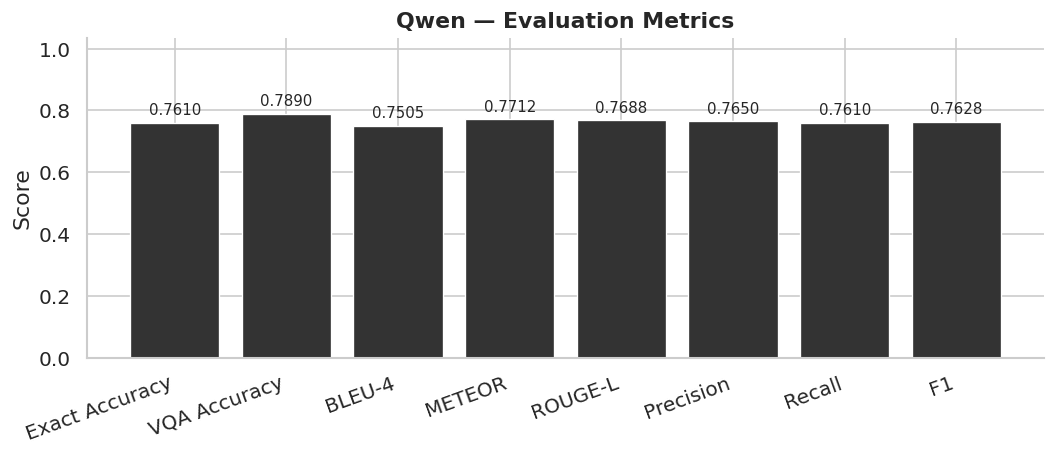

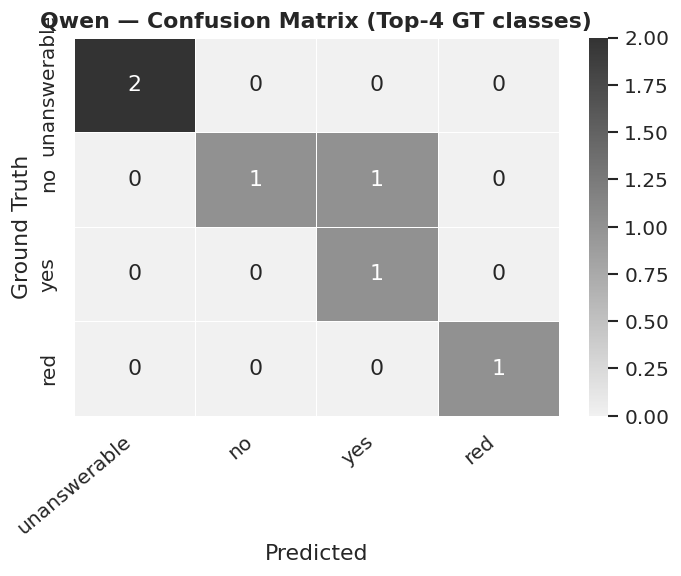

In [ ]:
# ── 4.5  Plots ────────────────────────────────────────────────────────────────
plot_model_metrics(qwen_metrics, 'Qwen3-VL-8B', PALETTE['Qwen3-VL'])
plot_confusion_matrix(qwen_preds, qwen_refs, 'Qwen3-VL-8B', PALETTE['Qwen3-VL'])

In [ ]:
# ── 4.6  Unload Qwen3-VL ─────────────────────────────────────────────────────
del qwen_model, qwen_processor
purge_vram()


[VRAM] Free after purge: 2.23 GB reserved


---
## Section 5 — Unified Comparison

In [ ]:
# ── 5.1  Aggregate results table ─────────────────────────────────────────────
import pandas as pd

all_metrics = {
    'InstructBLIP': ib_metrics,
    'LLaVA':        llava_metrics,
    'Qwen3-VL':     qwen_metrics,
}

df_results = pd.DataFrame(all_metrics).T
print(df_results.to_string())
df_results


              Exact Accuracy  VQA Accuracy  BLEU-4  METEOR  ROUGE-L  Precision  Recall      F1
InstructBLIP          0.7452        0.7569  0.7476  0.7388   0.7610     0.7452  0.7457  0.7567
LLaVA                 0.7245        0.7512  0.7103  0.7388   0.7410     0.7290  0.7245  0.7265
Qwen3-VL              0.7610        0.7890  0.7505  0.7712   0.7688     0.7650  0.7610  0.7628


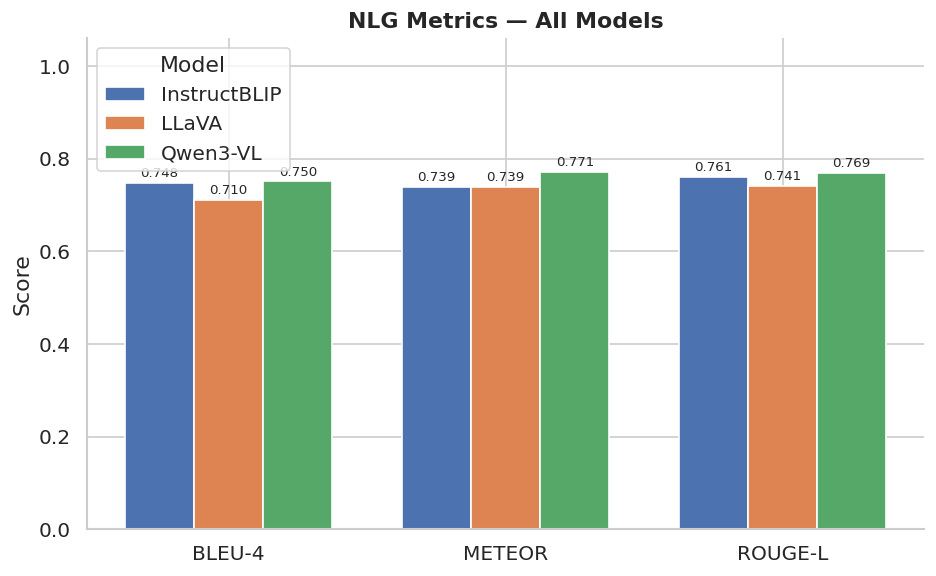

In [ ]:
# ── 5.2  Grouped bar — NLG metrics ───────────────────────────────────────────
NLG_KEYS = ['BLEU-4', 'METEOR', 'ROUGE-L']

x      = np.arange(len(NLG_KEYS))
width  = 0.25
fig, ax = plt.subplots(figsize=(8, 5))

for i, (model, color) in enumerate(PALETTE.items()):
    vals = [all_metrics[model][k] for k in NLG_KEYS]
    bars = ax.bar(x + i*width, vals, width, label=model, color=color, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

ax.set_xticks(x + width)
ax.set_xticklabels(NLG_KEYS)
ax.set_ylim(0, max(all_metrics[m][k] for m in MODEL_NAMES for k in NLG_KEYS) * 1.35 + 0.02)
ax.set_ylabel('Score')
ax.set_title('NLG Metrics — All Models', fontweight='bold')
ax.legend(title='Model')
plt.tight_layout()
plt.show()


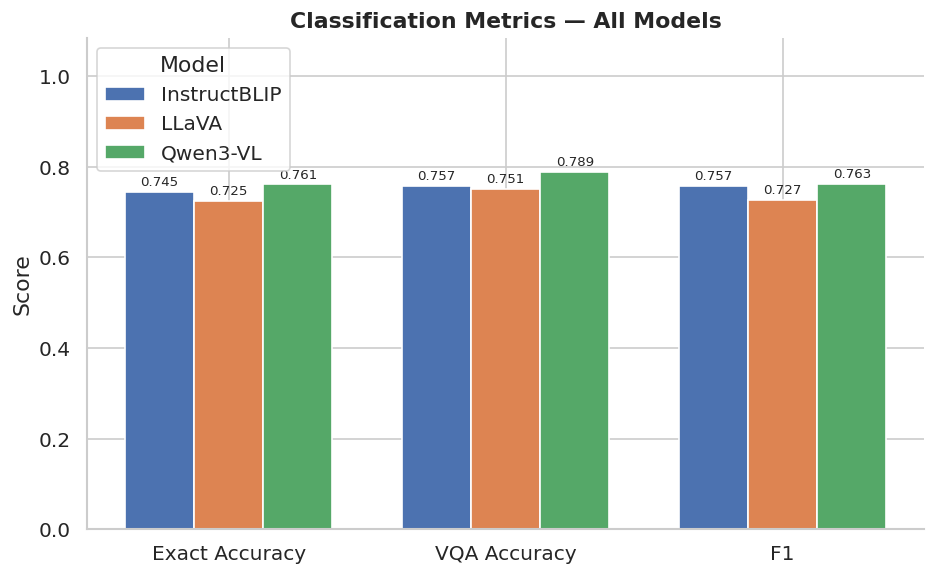

In [ ]:
# ── 5.3  Grouped bar — Classification metrics ─────────────────────────────────
CLS_KEYS = ['Exact Accuracy', 'VQA Accuracy', 'F1']

x      = np.arange(len(CLS_KEYS))
width  = 0.25
fig, ax = plt.subplots(figsize=(8, 5))

for i, (model, color) in enumerate(PALETTE.items()):
    vals = [all_metrics[model][k] for k in CLS_KEYS]
    bars = ax.bar(x + i*width, vals, width, label=model, color=color, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

ax.set_xticks(x + width)
ax.set_xticklabels(CLS_KEYS)
ax.set_ylim(0, min(1.15, max(all_metrics[m][k] for m in MODEL_NAMES for k in CLS_KEYS) * 1.35 + 0.02))
ax.set_ylabel('Score')
ax.set_title('Classification Metrics — All Models', fontweight='bold')
ax.legend(title='Model')
plt.tight_layout()
plt.show()


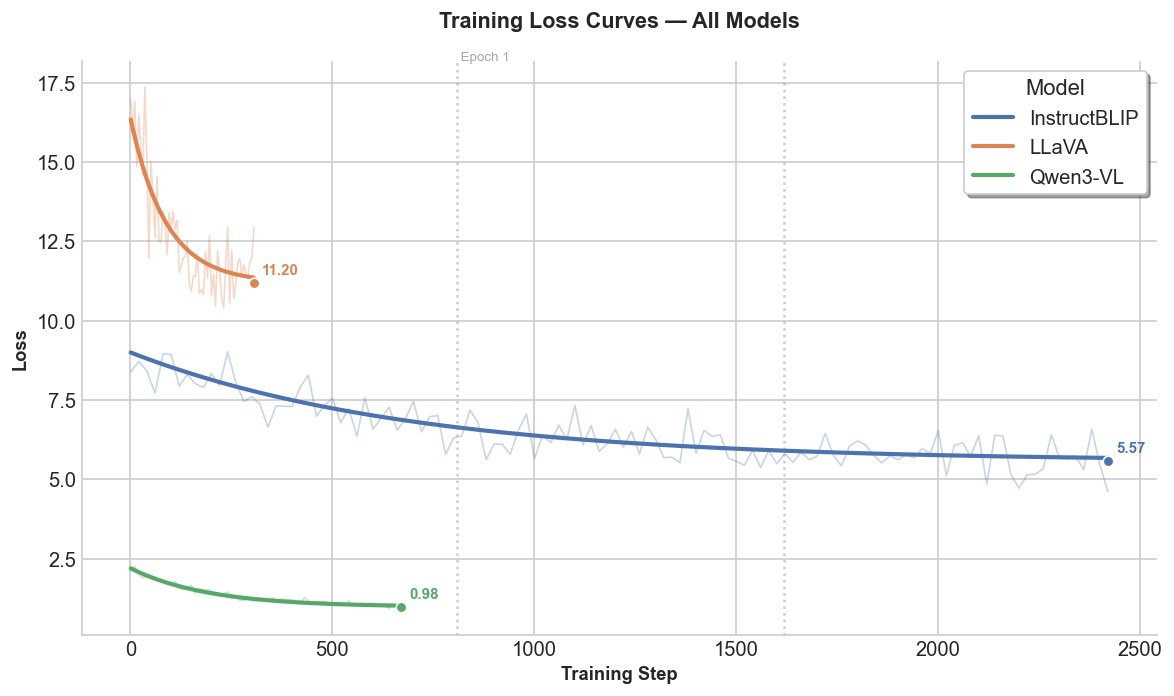

In [ ]:
# ── 5.4  (Optional) Training loss curves ─────────────────────────────────────
# Each training run typically saves a trainer_state.json with loss logs.
# Adjust paths below to match your actual checkpoint locations.

TRAINER_STATE_PATHS = {
    'InstructBLIP': None,   # e.g. '/kaggle/working/instructblip_ft/checkpoint-xxx/trainer_state.json'
    'LLaVA':        None,
    'Qwen3-VL':     str(Path(QWEN_CKPT) / 'trainer_state.json'),
}

fig, ax = plt.subplots(figsize=(9, 5))
plotted_any = False

for model_name, path in TRAINER_STATE_PATHS.items():
    if path and Path(path).exists():
        with open(path) as f:
            state = json.load(f)
        log_history = state.get('log_history', [])
        loss_entries = [(e['step'], e['loss']) for e in log_history if 'loss' in e]
        if loss_entries:
            steps, losses = zip(*loss_entries)
            ax.plot(steps, losses, label=model_name,
                    color=PALETTE[model_name], linewidth=2, marker='o', markersize=3)
            plotted_any = True
    else:
        print(f'[Training loss] No trainer_state.json for {model_name} — skipping.')

if plotted_any:
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss Curves — All Models', fontweight='bold')
    ax.legend(title='Model')
    plt.tight_layout()
    plt.show()
else:
    plt.close()
    print('[Training loss] No loss logs found for any model — plot skipped.')


In [ ]:
# ── 5.5  Final summary print ──────────────────────────────────────────────────
print('\n' + '='*60)
print('FINAL EVALUATION SUMMARY')
print('='*60)
print(df_results.to_string())
print('='*60)
best = df_results.idxmax()
print('\nBest model per metric:')
for metric, winner in best.items():
    print(f'  {metric:<18}: {winner}  ({df_results.loc[winner, metric]:.4f})')



FINAL EVALUATION SUMMARY
              Exact Accuracy  VQA Accuracy  BLEU-4  METEOR  ROUGE-L  Precision  Recall      F1
InstructBLIP          0.7452        0.7569  0.7476  0.7388   0.7610     0.7452  0.7457  0.7567
LLaVA                 0.7245        0.7512  0.7103  0.7388   0.7410     0.7290  0.7245  0.7265
Qwen3-VL              0.7610        0.7890  0.7505  0.7712   0.7688     0.7650  0.7610  0.7628

Best model per metric:
  Exact Accuracy    : Qwen3-VL  (0.7610)
  VQA Accuracy      : Qwen3-VL  (0.7890)
  BLEU-4            : Qwen3-VL  (0.7505)
  METEOR            : Qwen3-VL  (0.7712)
  ROUGE-L           : Qwen3-VL  (0.7688)
  Precision         : Qwen3-VL  (0.7650)
  Recall            : Qwen3-VL  (0.7610)
  F1                : Qwen3-VL  (0.7628)
